<a href="https://colab.research.google.com/github/YuvanshPrajapat/Handwritten-Digit-Recognition/blob/main/Vidhyashala_Internship_Program_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Mounted at /content/drive


In [ ]:
# Step 1
# Standard numerical and data handling
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# TensorFlow/Keras for building the CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# Step 2
# The dataset is loaded from the specified paths
try:
    # Use the /content/ path as specified in the original notebook
    train_df = pd.read_csv('/content/drive/MyDrive/train.csv')
    test_df = pd.read_csv('/content/drive/MyDrive/test.csv')
except FileNotFoundError:
    print("Error: Dataset files not found. Ensure they are correctly mounted.")
    # Exit or handle error as appropriate for a notebook

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
# Displaying the head of the training data
print("\nFirst 5 rows of the training dataset:")
print(train_df.head())

Train shape: (42000, 785)
Test shape: (28000, 784)

First 5 rows of the training dataset:
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         

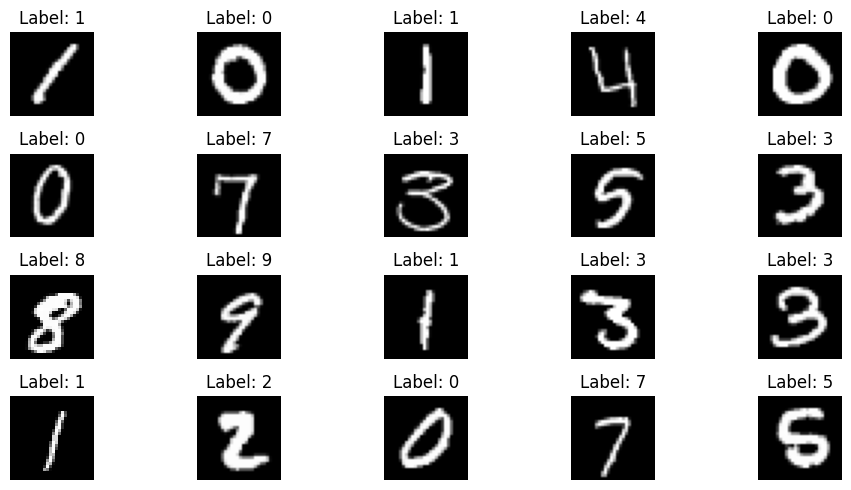

In [ ]:
# Step 3
# Separate features (pixels) from the target (label)
X_all = train_df.drop(columns=['label']).values
labels = train_df['label'].values

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(10, 5))

# Iterate through the axes and display the first 10 digits
for i, ax in enumerate(axes.flatten()):
    # Reshape the 784-pixel vector into a 28x28 image
    image = X_all[i].reshape((28, 28))
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {labels[i]}")
    ax.axis('off')

# Adjust layout to prevent title/label overlap
plt.tight_layout()
plt.show()

In [ ]:
# Step 4
# Reshape and normalize data
# Reshape: (-1, 28, 28, 1) -> (num_samples, height, width, channels)
# Normalize: Scale pixel values (0-255) to the range [0.0, 1.0]
X_processed = X_all.reshape(-1, 28, 28, 1).astype(np.float32) / 255.0

# Convert integer labels to one-hot encoded vectors (for categorical cross-entropy loss)
y_encoded = to_categorical(labels, num_classes=10)

# Split data into training and validation sets
# stratify=labels ensures an equal distribution of classes in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.1,  # 10% for validation
    stratify=labels,
    random_state=42
)

print(f'Training set shape: {X_train.shape}')
print(f'Validation set shape: {X_val.shape}')

Training set shape: (37800, 28, 28, 1)
Validation set shape: (4200, 28, 28, 1)


In [ ]:
# Step 5
cnn_model = Sequential()

# --- Convolutional Block 1 ---
cnn_model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# --- Convolutional Block 2 ---
cnn_model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# --- Fully Connected (Dense) Layers ---
cnn_model.add(Flatten()) # Flattens the 3D output to a 1D vector
cnn_model.add(Dense(units=128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(units=10, activation='softmax')) # Output layer: 10 classes, softmax for probabilities

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Model Summary:")
cnn_model.summary()

CNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Step 6
# Define callbacks for training control
model_callbacks = [
    # Stop training when validation loss stops improving (patience=5 epochs)
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True  # Load the weights from the best epoch
    ),
    # Save the model weights that resulted in the best validation accuracy
    ModelCheckpoint(
        filepath='best_mnist.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max' # Monitor for maximum validation accuracy
    )
]

# Train the model
training_history = cnn_model.fit(
    x=X_train,
    y=y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=model_callbacks,
    verbose=2 # Verbose 2 prints one line per epoch
)

Epoch 1/30


296/296 - 56s - 189ms/step - accuracy: 0.9063 - loss: 0.3135 - val_accuracy: 0.6567 - val_loss: 1.0249
Epoch 2/30


296/296 - 53s - 178ms/step - accuracy: 0.9689 - loss: 0.1043 - val_accuracy: 0.9719 - val_loss: 0.0794
Epoch 3/30


296/296 - 76s - 255ms/step - accuracy: 0.9774 - loss: 0.0723 - val_accuracy: 0.9874 - val_loss: 0.0458
Epoch 4/30
296/296 - 78s - 265ms/step - accuracy: 0.9807 - loss: 0.0609 - val_accuracy: 0.9864 - val_loss: 0.0454
Epoch 5/30


296/296 - 46s - 156ms/step - accuracy: 0.9845 - loss: 0.0498 - val_accuracy: 0.9890 - val_loss: 0.0406
Epoch 6/30
296/296 - 81s - 273ms/step - accuracy: 0.9859 - loss: 0.0439 - val_accuracy: 0.9855 - val_loss: 0.0467
Epoch 7/30
296/296 - 81s - 274ms/step - accuracy: 0.9867 - loss: 0.0431 - val_accuracy: 0.9864 - val_loss: 0.0436
Epoch 8/30
296/296 - 44s - 148ms/step - accuracy: 0.9890 - loss: 0.0334 - val_accuracy: 0.9883 - val_loss: 0.0481
Epoch 9/30
296/296 - 90s - 306ms/step - accuracy: 0.9901 - loss: 0.0321 - val_accuracy: 0.9886 - val_loss: 0.0459
Epoch 10/30
296/296 - 79s - 266ms/step - accuracy: 0.9913 - loss: 0.0274 - val_accuracy: 0.9864 - val_loss: 0.0517


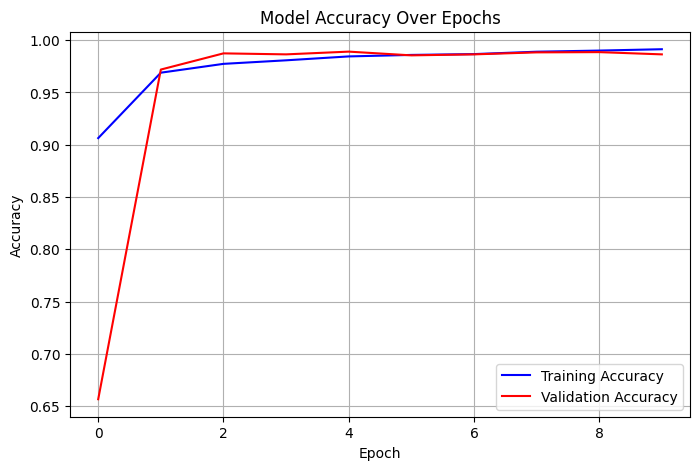

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

--- Validation Results ---
Validation Accuracy: 0.9890

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       413
           1       1.00      1.00      1.00       468
           2       0.98      1.00      0.99       418
           3       1.00      0.98      0.99       435
           4       0.99      1.00      1.00       407
           5       0.98      0.99      0.98       380
           6       0.99      1.00      0.99       414
           7       0.99      0.99      0.99       440
           8       0.99      0.97      0.98       406
           9       0.98      0.98      0.98       419

    accuracy                           0.99      4200
   macro avg       0.99      0.99      0.99      4200
weighted avg       0.99      0.99      0.99      4200



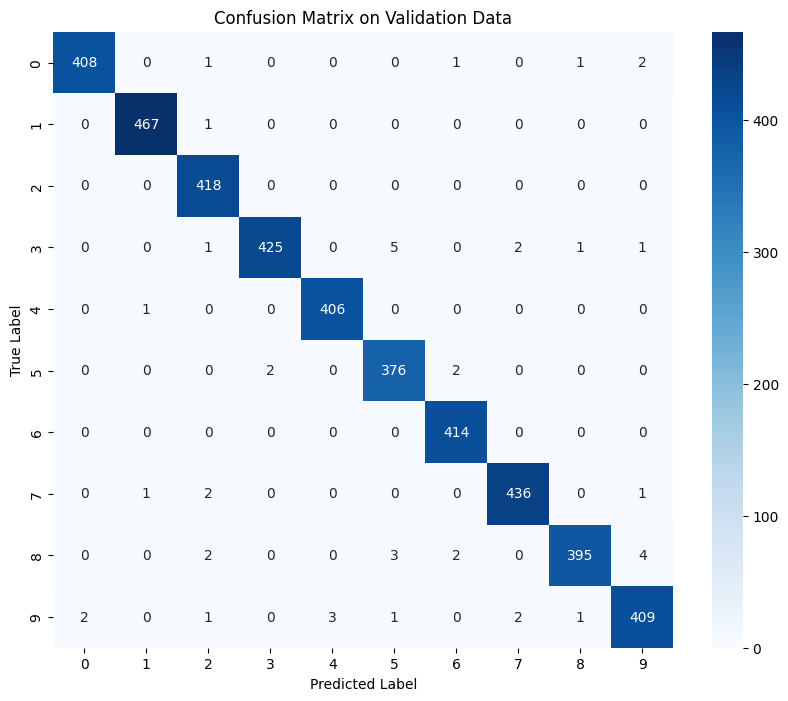

In [ ]:
# Step 7
# --- 1. Plot Training History ---
# Create a figure for the accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(training_history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(training_history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- 2. Evaluate on Validation Data ---
# Predict probabilities on the validation set
val_predictions = cnn_model.predict(X_val)
# Convert probabilities to class labels (index of the max probability)
val_pred_classes = np.argmax(val_predictions, axis=1)
# Convert one-hot encoded true labels back to class labels
y_val_classes = np.argmax(y_val, axis=1)

# Print overall accuracy score
print("\n--- Validation Results ---")
print(f"Validation Accuracy: {accuracy_score(y_val_classes, val_pred_classes):.4f}")

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_val_classes, val_pred_classes))

# --- 3. Confusion Matrix Visualization ---
cm = confusion_matrix(y_val_classes, val_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d', # Format to display integers
    cmap='Blues',
    cbar=True
)
plt.title('Confusion Matrix on Validation Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Step 8
# Preprocess the Kaggle test set
X_test = test_df.values.reshape(-1, 28, 28, 1).astype(np.float32) / 255.0

# Generate predictions (probabilities)
test_predictions_proba = cnn_model.predict(X_test)
# Convert probabilities to predicted class labels
predicted_labels = np.argmax(test_predictions_proba, axis=1)

# Create the submission DataFrame
# ImageId must be 1-indexed for Kaggle submission
submission_df = pd.DataFrame({
    'ImageId': np.arange(1, len(predicted_labels) + 1),
    'Label': predicted_labels
})

# Save the DataFrame to a CSV file without the index
submission_df.to_csv('submission.csv', index=False)

print(f"Submission file created: submission.csv with {len(submission_df)} entries.")

875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step
Submission file created: submission.csv with 28000 entries.
